In [150]:
!pip install yfinance requests pandas numpy matplotlib statsmodels scipy pmdarima --quiet

In [263]:
import yfinance as yf
import pandas as pd
import numpy as np
import requests
from scipy.stats import norm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

btc = yf.download(
    "BTC-USD",
    period="2y",
    progress=False,
    auto_adjust=False       
)["Close"]

btc.to_csv("btc_historical.csv")
print(f"Downloaded {len(btc)} days of BTC data")
print(f"Latest price: ${btc.iloc[-1].item():,.2f}")

Downloaded 732 days of BTC data
Latest price: $88,921.43


In [277]:
url = "https://api.elections.kalshi.com/trade-api/v2/markets"
params = {"limit": 1000, "status": "open", "series_ticker": "KXBTCD"}
response = requests.get(url, params=params)
kalshi_strikes = []

if response.status_code == 200:
    markets = response.json().get("markets", [])
    
    
    print(f"Found {len(markets)} total markets")
    
    for market in markets:
        ticker = market.get("ticker", "")
        if "KXBTCD" in ticker and market.get("floor_strike"):
            strike = market.get("floor_strike")
            
            yes_bid = market.get("yes_bid", 0) / 100
            yes_ask = market.get("yes_ask", 0) / 100

            if yes_bid > 0 and yes_ask > 0:
                market_prob = (yes_bid + yes_ask) / 2
            else:
                continue

            if strike and market_prob > 0:
                kalshi_strikes.append((int(strike), market_prob))
                
    if kalshi_strikes:
        kalshi_strikes.sort()
        
        current_price = btc.iloc[-1].item()
        kalshi_strikes = [(s, p) for s, p in kalshi_strikes 
                         if abs(s - current_price) / current_price < 0.10]
        
        kalshi_strikes = kalshi_strikes[:20] 
        print(f"\nAPI gave data - filtered to {len(kalshi_strikes)} strikes near current price")
        print(f"Current BTC price: ${current_price:,.0f}")
        print(f"Strike range: ${kalshi_strikes[0][0]:,.0f} - ${kalshi_strikes[-1][0]:,.0f}")
    else:
        print("No valid strikes found")
else:
    print(f"API error (status {response.status_code})")


Found 165 total markets

API gave data - filtered to 20 strikes near current price
Current BTC price: $88,921
Strike range: $80,249 - $82,499


In [343]:
def calculate_market_features(prices):
    features = {}
    current_price = prices.iloc[-1].item()
    
    features['change_1d'] = (prices.iloc[-1] / prices.iloc[-2] - 1).item() if len(prices) >= 2 else 0
    features['change_3d'] = (prices.iloc[-1] / prices.iloc[-4] - 1).item() if len(prices) >= 4 else 0
    features['change_7d'] = (prices.iloc[-1] / prices.iloc[-8] - 1).item() if len(prices) >= 8 else 0
    
    returns = prices.pct_change().dropna()
    features['vol_7d'] = returns.tail(7).std().item() if len(returns) >= 7 else 0.03
    features['vol_30d'] = returns.tail(30).std().item() if len(returns) >= 30 else 0.03
    
    features['ma_7'] = prices.tail(7).mean().item()
    features['ma_30'] = prices.tail(30).mean().item()
    features['price_to_ma7'] = (current_price / features['ma_7'] - 1)
    features['price_to_ma30'] = (current_price / features['ma_30'] - 1)
    
    if len(prices) >= 7:
        recent_prices = prices.tail(7).values
        x = np.arange(len(recent_prices))
        slope = np.polyfit(x, recent_prices, 1)[0]
        features['trend_slope'] = slope / current_price
    else:
        features['trend_slope'] = 0
    
    return features


def improved_forecast_v2(prices, horizon_hours=24):
    current_price = prices.iloc[-1].item()
    features = calculate_market_features(prices)
    
    # Momentum
    momentum_3d_daily = features['change_3d'] / 3
    momentum_strength = abs(momentum_3d_daily)
    damping = 0.5 if momentum_strength > 0.03 else 0.7 if momentum_strength > 0.02 else 1.0
    pred_momentum = current_price * (1 + momentum_3d_daily * damping)
    
    # Trend
    pred_trend = current_price * (1 + features['trend_slope'])
    
    # Mean reversion
    distance_from_ma7 = features['price_to_ma7']
    reversion_strength = 0.05 if abs(distance_from_ma7) > 0.05 else 0.02
    pred_reversion = current_price * (1 - distance_from_ma7 * reversion_strength)
    
    # Random walk
    pred_random_walk = current_price
    
    # Ensemble 
    predicted_price = (
        pred_random_walk * 0.30 +
        pred_momentum * 0.40 +
        pred_trend * 0.20 +
        pred_reversion * 0.10
    )
    
    # Uncertainty
    blended_vol = features['vol_30d'] * 0.4 + features['vol_7d'] * 0.6
    prediction_std = current_price * blended_vol * 2.5
    prediction_std = np.clip(prediction_std, current_price * 0.025, current_price * 0.12)
    if prediction_std < 2000:
        prediction_std = 2500
    
    components = {
        'random_walk': pred_random_walk,
        'momentum': pred_momentum,
        'trend': pred_trend,
        'reversion': pred_reversion
    }
    
    return predicted_price, prediction_std, features, components


def backtest_improved_v2(data, test_days=30):
    import sys
    
    errors = []
    predictions = []
    actuals = []
    dates = []
    
    for i in range(test_days, 0, -1):
        try:
            historical_end = len(data) - i
            historical = data.iloc[:historical_end]
            
            pred, std, _, _ = improved_forecast_v2(historical)
            
            if isinstance(pred, np.ndarray):
                pred = pred.item()
            else:
                pred = float(pred)
            
            actual = data.iloc[historical_end].item()
            actual_date = data.index[historical_end]

            predictions.append(pred) 
            actuals.append(actual)
            dates.append(actual_date)
            
            err = abs(pred - actual) / actual if actual != 0 else np.nan
            errors.append(err)
            
        except Exception as e:
            print(f"Error at day {test_days - i + 1}: {e}", flush=True)
            import traceback
            traceback.print_exc()
    
    print(f"Backtest complete: {len(predictions)} predictions made\n", flush=True)
    sys.stdout.flush()
    
    return np.array(errors), np.array(predictions), np.array(actuals), dates

errors, preds, actuals, dates = backtest_improved_v2(btc, test_days=30)

errors_pct = errors * 100

print("\n" + "="*100)
print("BACKTEST RESULTS")
print("="*100)
print(f"Mean Absolute Error:     {np.mean(errors_pct):.2f}%")
print(f"Median Error:            {np.median(errors_pct):.2f}%")
print(f"Best Prediction:         {np.min(errors_pct):.2f}%")
print(f"Worst Prediction:        {np.max(errors_pct):.2f}%")
print(f"Within ±5%:              {sum(errors_pct < 5)}/{len(errors_pct)} ({sum(errors_pct < 5)/len(errors_pct)*100:.1f}%)")

Backtest complete: 30 predictions made


BACKTEST RESULTS
Mean Absolute Error:     2.10%
Median Error:            1.68%
Best Prediction:         0.50%
Worst Prediction:        4.93%
Within ±5%:              30/30 (100.0%)


In [344]:
print("\n" + "="*100)
print("KALSHI BETTING RECOMMENDATIONS")
print("="*100)
print(f"{'Strike':>10}  {'Model Prob':>11}  {'Market Prob':>12}  {'Edge':>8}  {'Confidence':>11}  {'Recommendation':>15}")
print("-" * 100)

if len(kalshi_strikes) == 0:
    print("No strikes available")
else:
    recommendations = []
    
    for strike, market_prob in kalshi_strikes:
        z_score = (strike - pred) / std
        
        model_prob_value = 1 - norm.cdf(strike, pred, std)
        if hasattr(model_prob_value, 'item'):
            model_prob_value = model_prob_value.item()
        
        edge = model_prob_value - market_prob
        
        confidence = min(abs(z_score) / 2, 1.0) 
        if confidence < 0.3:
            confidence_label = "LOW"
        elif confidence < 0.7:
            confidence_label = "MEDIUM"
        else:
            confidence_label = "HIGH"
        
        if edge > 0.15 and confidence > 0.5:
            rec = "STRONG BET YES"
        elif edge > 0.08:
            rec = "BET YES"
        elif edge < -0.15 and confidence > 0.5:
            rec = "STRONG BET NO"
        elif edge < -0.08:
            rec = "BET NO"
        else:
            rec = "NO EDGE"
        
        recommendations.append((strike, model_prob_value, market_prob, edge, confidence_label, rec))
        print(f"${strike:>8,}    {model_prob_value:>10.1%}      {market_prob:>10.1%}    {edge:>+7.1%}    {confidence_label:>11}    {rec:>15}")


KALSHI BETTING RECOMMENDATIONS
    Strike   Model Prob   Market Prob      Edge   Confidence   Recommendation
----------------------------------------------------------------------------------------------------
$  80,249         98.5%           59.0%     +39.5%           HIGH     STRONG BET YES
$  80,249         98.5%           95.5%      +3.0%           HIGH            NO EDGE
$  80,499         98.3%           95.0%      +3.3%           HIGH            NO EDGE
$  80,499         98.3%           95.5%      +2.8%           HIGH            NO EDGE
$  80,749         98.0%           59.0%     +39.0%           HIGH     STRONG BET YES
$  80,749         98.0%           95.5%      +2.5%           HIGH            NO EDGE
$  80,999         97.8%           94.0%      +3.8%           HIGH            NO EDGE
$  80,999         97.8%           95.5%      +2.3%           HIGH            NO EDGE
$  81,249         97.5%           95.5%      +2.0%           HIGH            NO EDGE
$  81,249         97.5% 


BACKTEST PERFORMANCE SUMMARY
Total predictions: 30
Mean Absolute Error: 2.10%
Median Error: 1.68%
Best prediction: 0.50%
Worst prediction: 4.93%
Predictions within ±3%: 23/30 (76.7%)
Predictions within ±5%: 30/30 (100.0%)


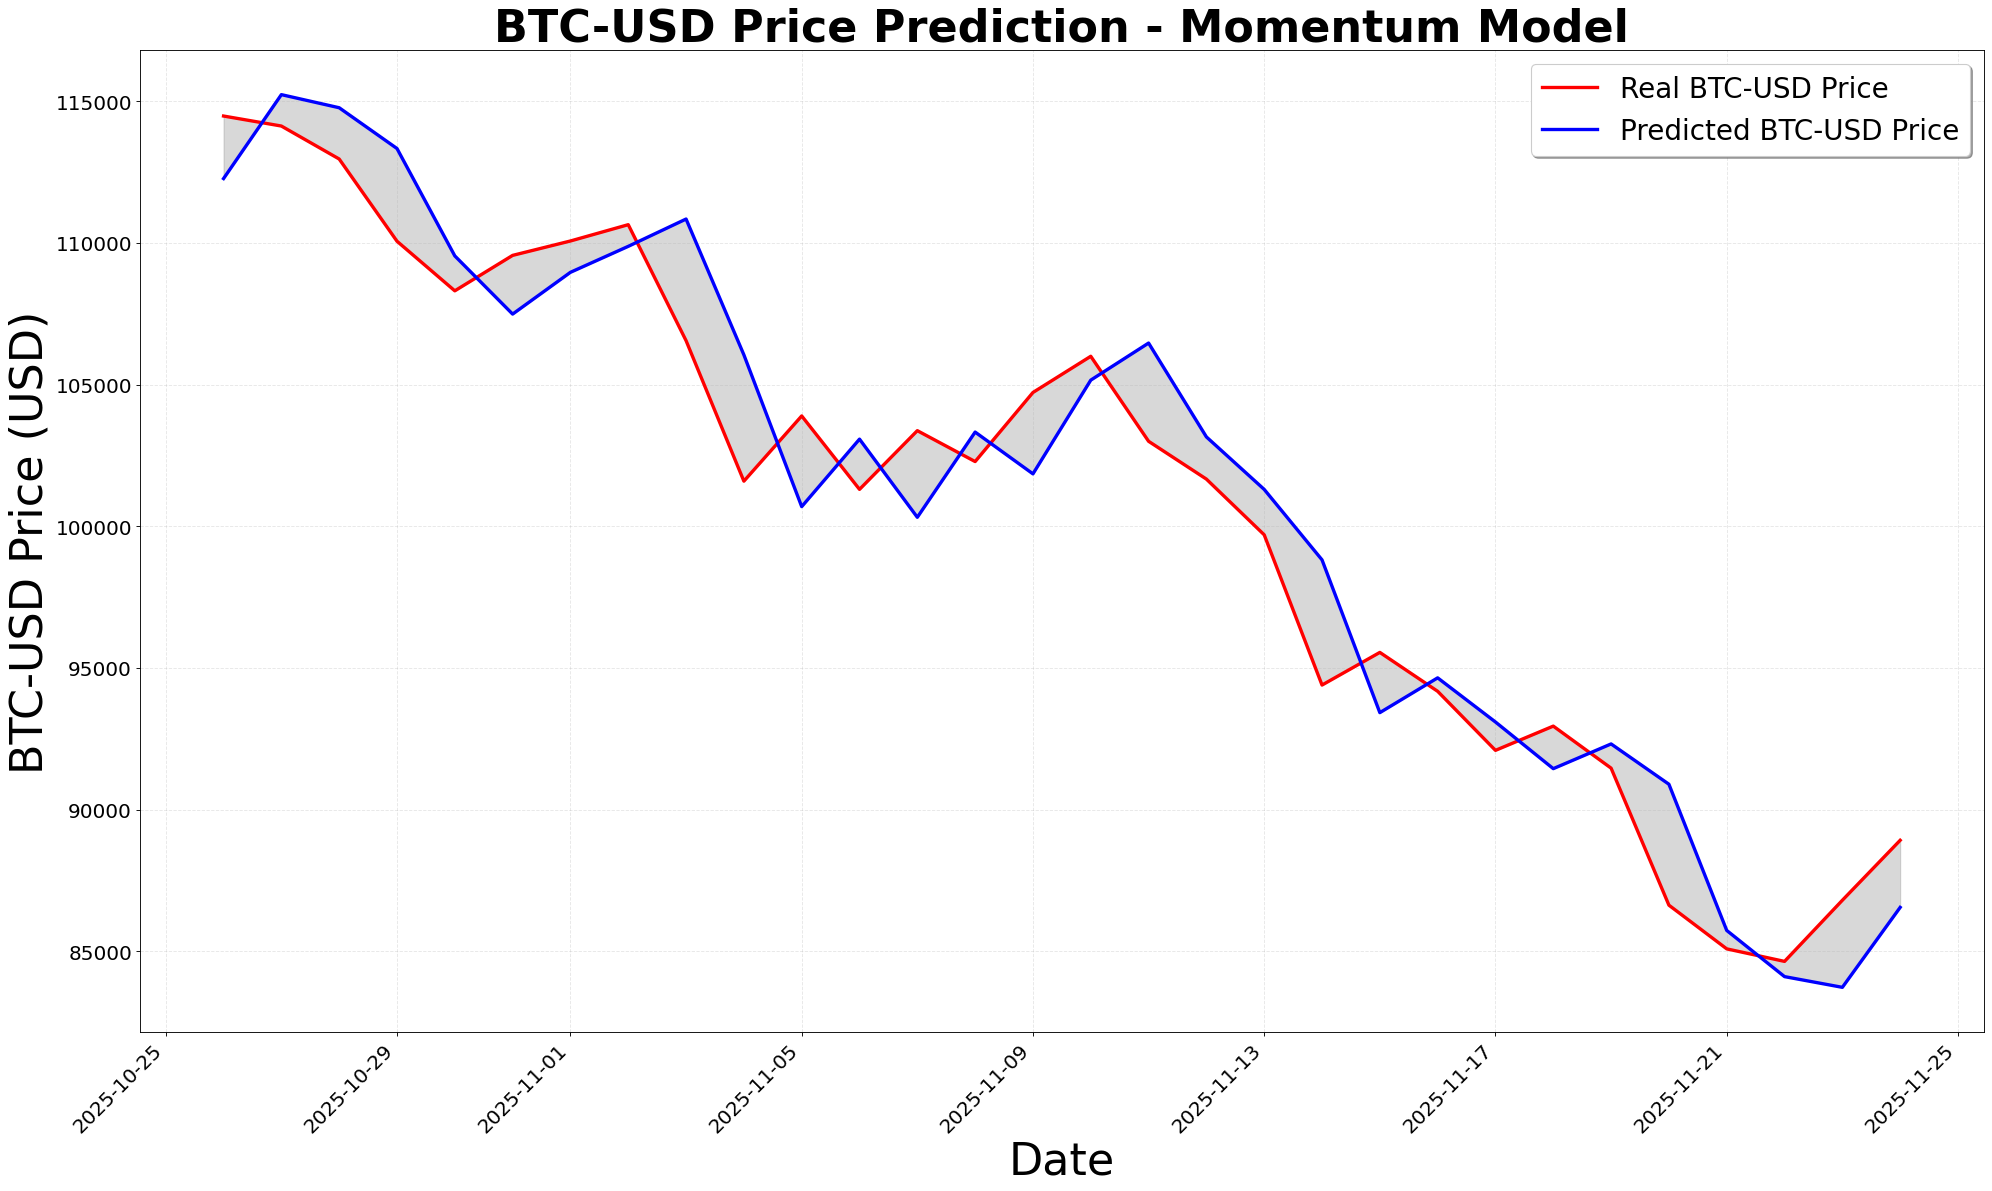

In [347]:
dates = np.array(btc.index[-30:])
actuals = np.array(actuals).astype(float).flatten()
preds   = np.array(preds).astype(float).flatten()
errors  = np.array(errors).astype(float).flatten()

if not (len(dates) == len(actuals) == len(preds) == len(errors)):
    raise ValueError(f"Length mismatch: dates={len(dates)}, actuals={len(actuals)}, preds={len(preds)}, errors={len(errors)}")


def plot_predictions(dates, actual_prices, predicted_prices, symbol='BTC'):
    plt.figure(figsize=(25, 15), dpi=80, facecolor='w', edgecolor='k')
    ax = plt.gca()

    ax.plot(dates, actual_prices, color='red', linewidth=3, label=f'Real {symbol} Price')
    ax.plot(dates, predicted_prices, color='blue', linewidth=3, label=f'Predicted {symbol} Price')

    ax.fill_between(dates, actual_prices, predicted_prices, alpha=0.3, color='gray')

    ax.set_title(f'{symbol} Price Prediction - Momentum Model', fontsize=40, fontweight='bold')
    ax.set_xlabel('Date', fontsize=40)
    ax.set_ylabel(f'{symbol} Price (USD)', fontsize=40)

    ax.tick_params(axis='both', labelsize=18)

    ax.legend(loc='best', fontsize=25, frameon=True, shadow=True)
    ax.grid(True, alpha=0.3, linestyle='--')

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

plot_predictions(dates, actuals, preds, symbol='BTC-USD')

ax1 = axes[0]
ax1.plot(dates, actuals, 'o-', color='red', linewidth=3, markersize=8, label='Actual Price')
ax1.plot(dates, preds, 's--', color='blue', linewidth=3, markersize=8, alpha=0.7, label='Predicted Price')
ax1.fill_between(dates, actuals, preds, alpha=0.2, color='gray')
ax1.set_title('BTC Price: Predicted vs Actual (Last 30 Days)', fontsize=35, fontweight='bold', pad=20)
ax1.set_ylabel('Price (USD)', fontsize=30)
ax1.legend(fontsize=22, loc='best', frameon=True, shadow=True)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.tick_params(axis='both', labelsize=18)


print("\n" + "="*80)
print("BACKTEST PERFORMANCE SUMMARY")
print("="*80)
print(f"Total predictions: {len(errors_pct)}")
print(f"Mean Absolute Error: {np.mean(errors_pct):.2f}%")  
print(f"Median Error: {np.median(errors_pct):.2f}%")     
print(f"Best prediction: {np.min(errors_pct):.2f}%")  
print(f"Worst prediction: {np.max(errors_pct):.2f}%")    
print(f"Predictions within ±3%: {sum(errors_pct < 3)}/{len(errors_pct)} ({sum(errors_pct < 3)/len(errors_pct)*100:.1f}%)") 
print(f"Predictions within ±5%: {sum(errors_pct < 5)}/{len(errors_pct)} ({sum(errors_pct < 5)/len(errors_pct)*100:.1f}%)") 
print("="*80)
